In [14]:
import numpy as np
import cartopy.crs as ccrs
import easygems.healpix as egh
import matplotlib as mpl
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib.patches import Patch
mpl.rcParams['figure.dpi'] = 150

In [2]:
# source = "scream"
# source = "nicam_gl11"
# source = "um_glm_n2560_RAL3p3"
# source = "icon_d3hp003"
# source = "ifs_tco3999_rcbmf"
# source = "casesm2_10km_nocumulus"
source = "IMERGv7"

# MCS masks
root_dir = "/pscratch/sd/w/wcmca1/hackathon/mcs_masks/"
in_zarr = f"{root_dir}{source}_mcs_masks_hp8.zarr"
in_zarr

# # Combined all feature masks
# root_dir = "/pscratch/sd/w/wcmca1/hackathon/all_masks/"
# in_zarr = f"{root_dir}{source}_allmasks_hp8_v1.zarr"
# in_zarr

'/pscratch/sd/w/wcmca1/hackathon/mcs_masks/IMERGv7_mcs_masks_hp8.zarr'

In [3]:
ds = xr.open_zarr(in_zarr, consolidated=True)
ds

<xarray.Dataset> Size: 10GB
Dimensions:      (cell: 786432, time: 1588)
Coordinates:
  * cell         (cell) int64 6MB 0 1 2 3 4 ... 786428 786429 786430 786431
    crs          int64 8B ...
  * time         (time) datetime64[ns] 13kB 2019-08-01 ... 2020-08-31T18:00:00
Data variables:
    cloud_types  (time, cell) float32 5GB dask.array<chunksize=(28, 786432), meta=np.ndarray>
    mcs_mask     (time, cell) float32 5GB dask.array<chunksize=(28, 786432), meta=np.ndarray>
Attributes: (12/18)
    Contact:                   Zhe Feng: zhe.feng@pnnl.gov
    Created_on:                Fri May 23 22:09:22 2025
    Institution:               Pacific Northwest National Laboratory
    Title:                     HEALPix remapped tracking mask data (zoom=8)
    linkpf:                    1
    minimum_cloud_area:        800
    ...                        ...
    processing_script:         make_mcs_swath_masks.py
    tb_threshold_coldanvil:    241.0
    tb_threshold_core:         225.0
    tb_threshold_environment:  261.0
    tb_threshold_warmanvil:    261.0
    zoom:                      8

In [4]:
ds.time[0:10]

<xarray.DataArray 'time' (time: 10)> Size: 80B
array(['2019-08-01T00:00:00.000000000', '2019-08-01T06:00:00.000000000',
       '2019-08-01T12:00:00.000000000', '2019-08-01T18:00:00.000000000',
       '2019-08-02T00:00:00.000000000', '2019-08-02T06:00:00.000000000',
       '2019-08-02T12:00:00.000000000', '2019-08-02T18:00:00.000000000',
       '2019-08-03T00:00:00.000000000', '2019-08-03T06:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
    crs      int64 8B ...
  * time     (time) datetime64[ns] 80B 2019-08-01 ... 2019-08-03T06:00:00
Attributes:
    long_name:  Base time in Epoch

In [5]:
ds.mcs_mask.attrs

{'comment': 'Track numbers are assigned by PyFLEXTRKR. Overlapping tracks resolved by highest coverage count.',
 'description': 'MCS track swath mask aggregated over time window. Each pixel labeled with MCS track number.',
 'grid_mapping': 'crs',
 'long_name': 'MCS swath mask',
 'units': '1',
 'valid_range': [0, 1000000]}

In [6]:
ds.cloud_types.attrs

{'comment': 'Classification based on brightness temperature and precipitation rate. Priority for ties: 1>2>3>4.',
 'description': 'Most frequent cloud type within non-MCS cold cloud shield over time window',
 'flag_meanings': 'no_cloud deep_convective stratiform non_deep_convective drizzle',
 'flag_values': [0, 1, 2, 3, 4],
 'grid_mapping': 'crs',
 'long_name': 'Cloud type classification',
 'units': '1',
 'valid_range': [0, 4]}

In [12]:
# itime = 1401
# # itime = 1201
# cloud_types = ds.cloud_types.isel(time=itime)
# egh.healpix_show(cloud_types.where(cloud_types > 0), vmin=0, vmax=4, cmap='tab20')

<Figure size 2100x1200 with 0 Axes>

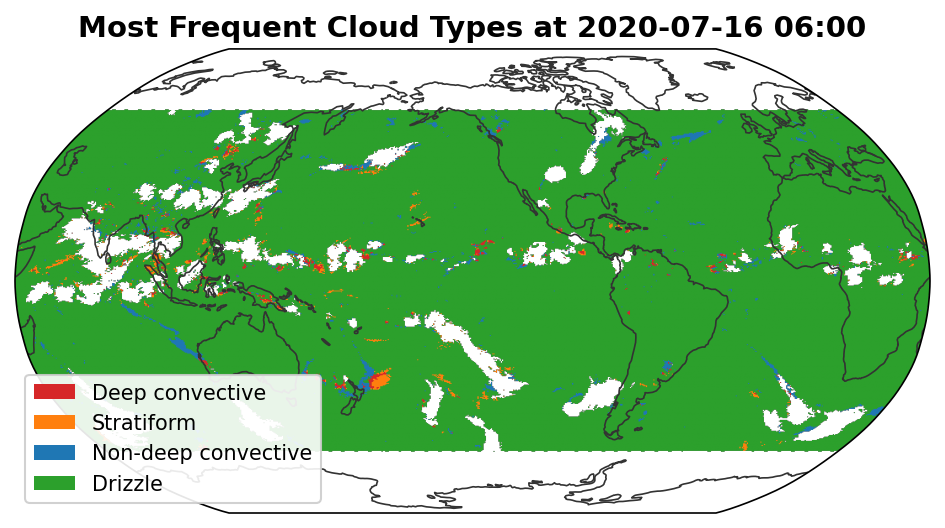

In [16]:
itime = 1401
# itime = 1201
cloud_types = ds.cloud_types.isel(time=itime)

# Define colors and labels for cloud types
cloud_colors = {
    1: '#d62728',  # Deep convective - red
    2: '#ff7f0e',  # Stratiform - orange
    3: '#1f77b4',  # Non-deep convective - blue
    4: '#2ca02c',  # Drizzle - green
}
cloud_labels = {
    1: 'Deep convective',
    2: 'Stratiform',
    3: 'Non-deep convective',
    4: 'Drizzle'
}

# Create custom colormap
cmap = mpl.colors.ListedColormap([cloud_colors[i] for i in range(1, 5)])

# Plot cloud type classification
fig = plt.figure(figsize=(14, 8))
im = egh.healpix_show(cloud_types.where(cloud_types > 0), 
                       cmap=cmap, 
                       vmin=0.5, vmax=4.5)
time_str = ds.time.isel(time=itime).dt.strftime('%Y-%m-%d %H:%M').item()
plt.title(f'Most Frequent Cloud Types at {time_str}', fontsize=14, fontweight='bold')

# Create custom legend
legend_elements = [Patch(facecolor=cloud_colors[i], label=cloud_labels[i]) 
                   for i in range(1, 5)]
plt.legend(handles=legend_elements, loc='lower left', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

<Figure size 960x720 with 0 Axes>

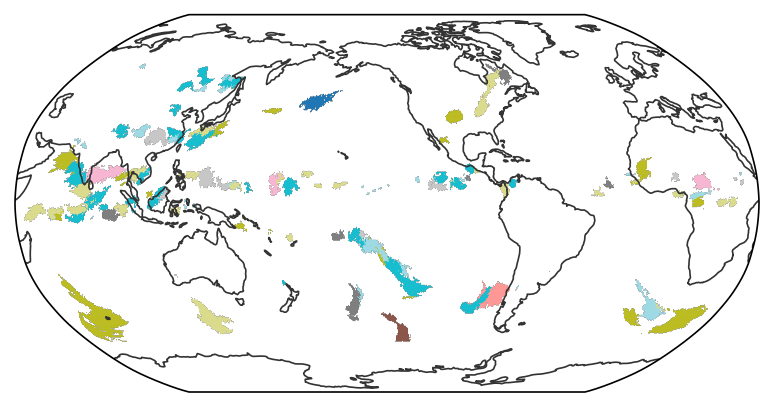

In [17]:
# itime = 1021
itime = 1401
mcs_mask = ds.mcs_mask.isel(time=itime)
egh.healpix_show(mcs_mask.where(mcs_mask > 0), cmap='tab20')

In [9]:
sdate = '2020-03-01T00'
edate = '2020-03-31T23'

mcs_binary = ds.mcs_mask.sel(time=slice(sdate, edate)) > 0
mcs_count = mcs_binary.sum(dim='time')
nhours = ds.time.sel(time=slice(sdate, edate)).count()

mcs_freq = 100 * mcs_count / nhours

<Figure size 960x720 with 0 Axes>

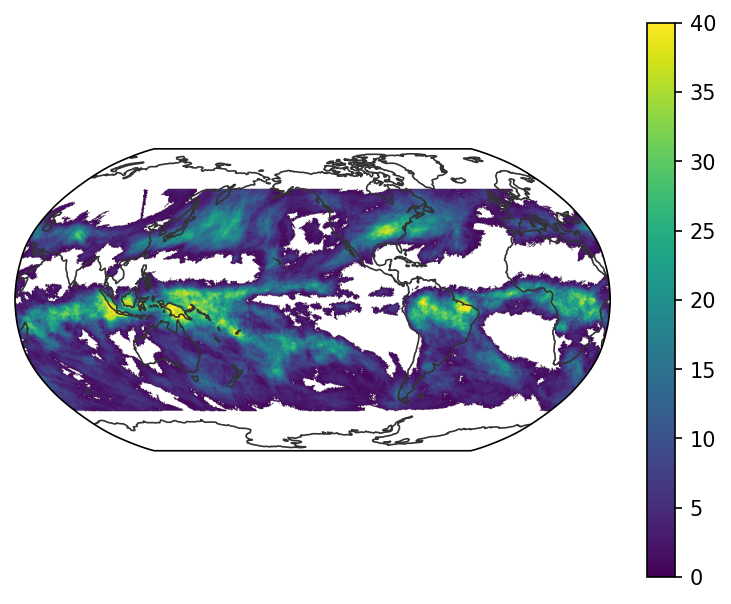

In [10]:
img = egh.healpix_show(mcs_freq.where(mcs_freq > 0), vmin=0, vmax=40)
plt.colorbar(img)

In [11]:
mcs_freq.max().values

array(55.64516129)